In [ ]:

!pip install wfdb

import os

# Folder where PTB-XL will live
DATA_ROOT = "/content/ptbxl"

if not os.path.exists(DATA_ROOT):
    os.makedirs(DATA_ROOT, exist_ok=True)

# Download the official zip file
ZIP_PATH = "/content/ptbxl.zip"

if not os.path.exists(ZIP_PATH):
    print("Downloading PTB-XL (~1.7 GB)... This takes ~2–5 minutes.")
    !wget -O /content/ptbxl.zip https://physionet.org/static/published-projects/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip
else:
    print("Zip file already downloaded.")

# Unzip into /content/ptbxl/
print("Extracting ZIP... (2–5 minutes)")
!unzip -q /content/ptbxl.zip -d /content/ptbxl/

# PTB-XL extracted into this final path:
DATA_ROOT = "/content/ptbxl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
print("PTB-XL ready at:", DATA_ROOT)

# Verify existence
print("\nFiles found:")
!ls -lh $DATA_ROOT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 139.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
--2025-12-06 16:19:37--  https://physionet.org/static/published-projects/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanent

In [ ]:
import pandas as pd

# LOAD METADATA
csv_path = "/content/ptbxl_database.csv"
df = pd.read_csv(csv_path)

print("Columns in dataset:")
print(df.columns)

# SELECT DEMOGRAPHIC COLUMNS SAFELY
demo_cols = []

if "age" in df.columns:
    demo_cols.append("age")
if "sex" in df.columns:
    demo_cols.append("sex")
if "site" in df.columns:
    demo_cols.append("site")
if "race" in df.columns:
    demo_cols.append("race")
if "ethnicity" in df.columns:
    demo_cols.append("ethnicity")

demo_df = df[demo_cols].copy()

# AGE GROUPING
bins = [0, 39, 59, 79, 200]
labels = ["<40", "40–59", "60–79", "≥80"]
demo_df["age_group"] = pd.cut(demo_df["age"], bins=bins, labels=labels)

# SUMMARY STATISTICS
N = len(demo_df)

age_summary = demo_df["age_group"].value_counts().sort_index()
sex_summary = demo_df["sex"].value_counts() if "sex" in demo_df else None
site_summary = demo_df["site"].value_counts() if "site" in demo_df else None
race_summary = demo_df["race"].value_counts() if "race" in demo_df else None

# BUILD FINAL TABLE (PAPER FORMAT)
table = []

# Age
for grp in labels:
    count = age_summary.get(grp, 0)
    table.append(["Age Group: " + grp, f"{count} ({count/N*100:.1f}%)"])

# Sex
if sex_summary is not None:
    for k, v in sex_summary.items():
        table.append(["Sex: " + str(k), f"{v} ({v/N*100:.1f}%)"])

# Site
if site_summary is not None:
    for k, v in site_summary.items():
        table.append(["Site: " + str(k), f"{v} ({v/N*100:.1f}%)"])

# Race (if exists)
if race_summary is not None:
    for k, v in race_summary.items():
        table.append(["Race: " + str(k), f"{v} ({v/N*100:.1f}%)"])

final_table = pd.DataFrame(table, columns=["Characteristic", "Value (N, %)"])

final_table


Columns in dataset:
Index(['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse',
       'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis',
       'infarction_stadium1', 'infarction_stadium2', 'validated_by',
       'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
       'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems',
       'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr'],
      dtype='object')


,Characteristic,"Value (N, %)"
0,Age Group: <40,2847 (13.1%)
1,Age Group: 40–59,6903 (31.7%)
2,Age Group: 60–79,9341 (42.9%)
3,Age Group: ≥80,2415 (11.1%)
4,Sex: 0,11354 (52.1%)
5,Sex: 1,10445 (47.9%)
6,Site: 0.0,8940 (41.0%)
7,Site: 1.0,6294 (28.9%)
8,Site: 2.0,5075 (23.3%)
9,Site: 3.0,576 (2.6%)


In [ ]:
import pandas as pd
import numpy as np

# Load metadata
df = pd.read_csv("ptbxl_database.csv")

# Convert age to numeric
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# Remove impossible ages
df = df[(df["age"] >= 0) & (df["age"] <= 120)]

print("Clean Age Range:", df["age"].min(), "-", df["age"].max())


Clean Age Range: 2.0 - 89.0


In [ ]:
N = len(df)

# -------- AGE STATS --------
age_mean = df["age"].mean()
age_std = df["age"].std()
age_min = df["age"].min()
age_max = df["age"].max()

# Age groups
bins = [0, 39, 59, 79, 120]
labels = ["<40", "40–59", "60–79", "≥80"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

age_groups = df["age_group"].value_counts().sort_index()

sex_counts = df["sex"].value_counts()

site_counts = df["site"].value_counts()

table = []

table.append(["Age — yr", ""])
table.append(["Mean ± SD", f"{age_mean:.1f} ± {age_std:.1f}"])
table.append(["Range", f"{int(age_min)}–{int(age_max)}"])

table.append(["Age Groups — no. (%)", ""])
for k, v in age_groups.items():
    pct = 100 * v / N
    table.append([k, f"{v} ({pct:.1f}%)"])

table.append(["Sex — no. (%)", ""])
for k, v in sex_counts.items():
    pct = 100 * v / N
    table.append([f"Sex: {k}", f"{v} ({pct:.1f}%)"])

table.append(["Recording Site — no. (%)", ""])
for k, v in site_counts.head(6).items():
    pct = 100 * v / N
    table.append([f"Site {k}", f"{v} ({pct:.1f}%)"])

# Final dataframe
demo_table = pd.DataFrame(table, columns=["Characteristic", f"Value (N={N})"])
demo_table


,Characteristic,Value (N=21506)
0,Age — yr,
1,Mean ± SD,59.5 ± 16.8
2,Range,2–89
3,Age Groups — no. (%),
4,<40,2847 (13.2%)
5,40–59,6903 (32.1%)
6,60–79,9341 (43.4%)
7,≥80,2415 (11.2%)
8,Sex — no. (%),
9,Sex: 0,11286 (52.5%)


In [ ]:
# ============================================================
#  PART 1 — SETUP & IMPORTS
# ============================================================

!pip install PyWavelets networkx

import os, glob, ast, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from scipy.signal import resample
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import pywt
import networkx as nx

# use CPU/GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Path inherited from Cell 0
print("DATA_ROOT =", DATA_ROOT)

Using device: cuda
DATA_ROOT = /content/ptbxl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3


In [ ]:
# ============================================================
#  PART 2 — LOAD PTB-XL METADATA
# ============================================================

df = pd.read_csv(os.path.join(DATA_ROOT, "ptbxl_database.csv"))
scp = pd.read_csv(os.path.join(DATA_ROOT, "scp_statements.csv"), index_col=0)

# Convert scp_codes string → list of diagnostic codes
df["labels"] = df["scp_codes"].apply(lambda x: list(ast.literal_eval(x).keys()))

# Prefer 100 Hz low-resolution signals
def pick_lr(row):
    lr = os.path.join(DATA_ROOT, row["filename_lr"])
    hr = os.path.join(DATA_ROOT, row["filename_hr"])

    # Check correct PTB-XL header file
    if os.path.exists(lr + ".hea"):
        return lr
    else:
        return hr

In [ ]:
df["signal_path"] = df.apply(pick_lr, axis=1)
df.head()

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,labels,signal_path
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,"[NORM, LVOLT, SR]",/content/ptbxl/ptb-xl-a-large-publicly-availab...
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,"[NORM, SBRAD]",/content/ptbxl/ptb-xl-a-large-publicly-availab...
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,"[NORM, SR]",/content/ptbxl/ptb-xl-a-large-publicly-availab...
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,"[NORM, SR]",/content/ptbxl/ptb-xl-a-large-publicly-availab...
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,"[NORM, SR]",/content/ptbxl/ptb-xl-a-large-publicly-availab...


In [ ]:
# ============================================================
#  PART 3 — LABEL PROCESSING
# ============================================================

diagnostic_scps = scp[scp["diagnostic"] == 1]
super_map = diagnostic_scps["diagnostic_class"].to_dict()

def get_super(lbls):
    return sorted(list({super_map[c] for c in lbls if c in super_map}))

def get_detail(lbls):
    return sorted([c for c in lbls if c in diagnostic_scps.index])

df["diag_super"] = df["labels"].apply(get_super)
df["diag_detail"] = df["labels"].apply(get_detail)

# Multi-hot encoding
mlb_super = MultiLabelBinarizer()
Y_super = mlb_super.fit_transform(df["diag_super"])
SUPER_CLASSES = list(mlb_super.classes_)

# Multi-hot encoding
mlb_detail = MultiLabelBinarizer()
Y_detail = mlb_detail.fit_transform(df["diag_detail"])
DETAIL_CLASSES = list(mlb_detail.classes_)

print("Super classes:", SUPER_CLASSES)
print("Detailed labels:", len(DETAIL_CLASSES))


Super classes: ['CD', 'HYP', 'MI', 'NORM', 'STTC']
Detailed labels: 44


In [ ]:
# ============================================================
#  PART 4 — DEMOGRAPHICS: AGE, SEX, SITE
# ============================================================

# Age groups
bins = [0, 40, 60, 80, 200]
age_labels = ["<40", "40-59", "60-79", "80+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=age_labels, right=False)

# Map to indices
age_map = {ag: i for i, ag in enumerate(age_labels)}
df["age_group_idx"] = df["age_group"].map(age_map).fillna(1).astype(int)

# Sex
sex_map = {"M": 0, "F": 1}
df["sex_idx"] = df["sex"].map(sex_map).fillna(0).astype(int)

# Site
if "site" in df.columns:
    site_names = sorted(df["site"].unique())
    site_map = {s: i for i, s in enumerate(site_names)}
    df["site_idx"] = df["site"].map(site_map)
else:
    df["site_idx"] = 0

df["site_idx"] = df["site_idx"].fillna(0).astype(int)

df[["age", "age_group", "age_group_idx", "sex", "sex_idx", "site_idx"]].head()


,age,age_group,age_group_idx,sex,sex_idx,site_idx
0,56.0,40-59,1,1,0,0
1,19.0,<40,0,0,0,0
2,37.0,<40,0,1,0,0
3,24.0,<40,0,0,0,0
4,19.0,<40,0,1,0,0


In [ ]:
# ============================================================
#  PART 5 — TRAIN / VAL / TEST SPLIT
# ============================================================

train_mask = df["strat_fold"] <= 8
val_mask   = df["strat_fold"] == 9
test_mask  = df["strat_fold"] == 10

train_df = df[train_mask].reset_index(drop=True)
valid_df = df[val_mask].reset_index(drop=True)
test_df  = df[test_mask].reset_index(drop=True)

Ytr_super = Y_super[train_mask.values]
Yv_super  = Y_super[val_mask.values]
Yt_super  = Y_super[test_mask.values]

Ytr_detail = Y_detail[train_mask.values]
Yv_detail  = Y_detail[val_mask.values]
Yt_detail  = Y_detail[test_mask.values]

print("Train:", len(train_df), "Val:", len(valid_df), "Test:", len(test_df))

Train: 17418 Val: 2183 Test: 2198


In [ ]:
# ============================================================
#  PART 6 — LOAD 100 Hz SIGNALS
# ============================================================

def load_signals(df_sub, target_fs=100):
    X = []
    for _, row in df_sub.iterrows():
        sig, meta = wfdb.rdsamp(row["signal_path"])
        fs = float(meta.get("fs", target_fs))

        sig = sig.astype(np.float32)
        if fs != target_fs:
            T_new = int(round(sig.shape[0] * target_fs / fs))
            sig = resample(sig, T_new)

        X.append(sig)
    return np.stack(X, axis=0)

print("Loading training signals...")
X_train = load_signals(train_df)

print("Loading validation signals...")
X_valid = load_signals(valid_df)

print("Loading test signals...")
X_test = load_signals(test_df)

print("X_train:", X_train.shape)


Loading training signals...
Loading validation signals...
Loading test signals...
X_train: (17418, 1000, 12)


In [ ]:
# ============================================================
#  PART 7 — DATASET & DATALOADERS
# ============================================================

class ECGDataset(Dataset):
    def __init__(self, X, Y_super, Y_detail, meta_df):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y_super = torch.tensor(Y_super, dtype=torch.float32)
        self.Y_detail = torch.tensor(Y_detail, dtype=torch.float32)

        self.age = torch.tensor(meta_df["age_group_idx"].values, dtype=torch.long)
        self.sex = torch.tensor(meta_df["sex_idx"].values, dtype=torch.long)
        self.site = torch.tensor(meta_df["site_idx"].values, dtype=torch.long)

        # demographic group ID for DRO (12 possible groups)
        self.group_id = self.sex * len(age_map) + self.age

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].permute(1, 0)  # (T,12)→(12,T)
        return (
            x,
            self.Y_super[idx],
            self.Y_detail[idx],
            self.age[idx],
            self.sex[idx],
            self.site[idx],
            self.group_id[idx]
        )

batch_size = 64

train_loader = DataLoader(ECGDataset(X_train, Ytr_super, Ytr_detail, train_df),
                          batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(ECGDataset(X_valid, Yv_super, Yv_detail, valid_df),
                        batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(ECGDataset(X_test, Yt_super, Yt_detail, test_df),
                         batch_size=batch_size, shuffle=False, num_workers=2)

print("Batches per epoch:", len(train_loader))


Batches per epoch: 273


In [ ]:
unique_fs = []
for p in df["signal_path"].head(20):
    sig, meta = wfdb.rdsamp(p)
    unique_fs.append(meta["fs"])

unique_fs

[100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100]

In [ ]:
# ============================================================
#  PART 8.1 — BASELINE RESNET1D
# ============================================================

class ResidualBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=7, stride=1, dropout=0.1):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=pad)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.dropout = nn.Dropout(dropout)
        self.down = None
        if stride != 1 or in_ch != out_ch:
            self.down = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        if self.down is not None:
            identity = self.down(identity)
        out = F.relu(out + identity)
        return out

class ResNet1DClassifier(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        base_ch = 64
        self.stem = nn.Sequential(
            nn.Conv1d(12, base_ch, kernel_size=7, padding=3),
            nn.BatchNorm1d(base_ch),
            nn.ReLU()
        )
        self.block1 = ResidualBlock1D(base_ch,   base_ch,   stride=1)
        self.block2 = ResidualBlock1D(base_ch,   base_ch*2, stride=2)
        self.block3 = ResidualBlock1D(base_ch*2, base_ch*4, stride=2)
        self.pool   = nn.AdaptiveAvgPool1d(1)
        self.fc     = nn.Linear(base_ch*4, n_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x).squeeze(-1)
        logits = self.fc(x)
        return logits


In [ ]:
# ============================================================
#  PART 8.2 — MULTI-RESOLUTION CNN
# ============================================================

class MultiResCNN(nn.Module):
    def __init__(self, n_classes, hidden=64):
        super().__init__()
        # three branches with different receptive fields
        self.b1 = nn.Sequential(
            nn.Conv1d(12, hidden, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden),
            nn.ReLU()
        )
        self.b2 = nn.Sequential(
            nn.Conv1d(12, hidden, kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden),
            nn.ReLU()
        )
        self.b3 = nn.Sequential(
            nn.Conv1d(12, hidden, kernel_size=15, padding=7),
            nn.BatchNorm1d(hidden),
            nn.ReLU()
        )
        self.post = nn.Sequential(
            nn.Conv1d(hidden*3, hidden*3, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden*3),
            nn.ReLU()
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(hidden*3, n_classes)

    def forward(self, x):
        b1 = self.b1(x)
        b2 = self.b2(x)
        b3 = self.b3(x)
        h  = torch.cat([b1, b2, b3], dim=1)
        h  = self.post(h)
        h  = self.pool(h).squeeze(-1)
        logits = self.fc(h)
        return logits


In [ ]:
# ============================================================
#  PART 8.3 — MRMT_GNN (MULTI-RES + LABEL GRAPH)
# ============================================================

Ytr_bin = Ytr_super
cooc = Ytr_bin.T @ Ytr_bin
cooc = cooc.astype(np.float32)
cooc = cooc / (cooc.max() + 1e-8)
np.fill_diagonal(cooc, 1.0)
A_super = torch.tensor(cooc, dtype=torch.float32, device=device)

class MRTransformerEncoder(nn.Module):
    def __init__(self, hidden=128, dropout=0.1):
        super().__init__()
        self.b1 = nn.Conv1d(12, hidden, kernel_size=3, padding=1, dilation=1)
        self.b2 = nn.Conv1d(12, hidden, kernel_size=5, padding=4, dilation=2)
        self.b3 = nn.Conv1d(12, hidden, kernel_size=9, padding=16, dilation=4)
        self.pool = nn.AdaptiveAvgPool1d(128)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden*3, nhead=4, dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(hidden*3, hidden)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        b1 = F.relu(self.b1(x))
        b2 = F.relu(self.b2(x))
        b3 = F.relu(self.b3(x))
        h  = torch.cat([b1, b2, b3], dim=1)
        h  = self.pool(h).transpose(1, 2)
        h  = self.transformer(h)
        h  = h.mean(dim=1)
        h  = self.dropout(F.relu(self.fc(h)))
        return h

class LabelGraphGNN(nn.Module):
    def __init__(self, n_classes, hidden=64):
        super().__init__()
        self.fc1 = nn.Linear(n_classes, hidden)
        self.fc2 = nn.Linear(hidden, n_classes)

    def forward(self, logits, A):
        # logits: (B, C), A: (C, C)
        msg = logits @ A
        h   = F.relu(self.fc1(msg))
        out = self.fc2(h) + logits
        return out

class MRMT_GNN(nn.Module):
    def __init__(self, n_classes, hidden=128):
        super().__init__()
        self.encoder = MRTransformerEncoder(hidden=hidden)
        self.cls     = nn.Linear(hidden, n_classes)
        self.gnn     = LabelGraphGNN(n_classes=n_classes, hidden=64)
        self.register_buffer("A_super", A_super)

    def forward(self, x):
        h = self.encoder(x)
        logits = self.cls(h)
        logits = self.gnn(logits, self.A_super)
        return logits


In [ ]:
# ============================================================
#  PART 8.4 — WAVELET-ATTENTION NETWORK
# ============================================================

class WaveletAttentionNet(nn.Module):
    def __init__(self, n_classes, hidden=64, wavelet="db4", levels=3):
        super().__init__()
        self.wavelet = wavelet
        self.levels  = levels
        self.hidden  = hidden


        self.proj = nn.ModuleList([
            nn.Conv1d(12, hidden, kernel_size=1) for _ in range(levels+1)
        ])
        d_model = hidden * (levels+1)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=4, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(d_model, n_classes)

    def forward(self, x):
        B, C, T = x.shape
        xs = []
        for b in range(B):
            scales = []
            for c in range(C):
                coeffs = pywt.wavedec(x[b, c].detach().cpu().numpy(),
                                      self.wavelet, level=self.levels)
                for lvl, arr in enumerate(coeffs):
                    arr = torch.tensor(arr, dtype=torch.float32, device=x.device).unsqueeze(0)
                    if len(xs) <= lvl:
                        pass
            break

        h0 = self.proj[0](x)
        h1 = self.proj[1](F.avg_pool1d(x, 2))
        h2 = self.proj[2](F.avg_pool1d(x, 4))

        h1 = F.interpolate(h1, size=h0.shape[-1], mode="linear")
        h2 = F.interpolate(h2, size=h0.shape[-1], mode="linear")
        h = torch.cat([h0, h1, h2], dim=1)
        h = h.transpose(1, 2)
        h = self.encoder(h)
        h = h.mean(dim=1)
        logits = self.fc(h)
        return logits

In [ ]:
# ============================================================
#  PART 8.4 — FIXED WAVELET ATTENTION NETWORK
# ============================================================

class WaveletAttentionNet(nn.Module):
    def __init__(self, n_classes, embed_dim=192, num_heads=4):
        super().__init__()

        self.embed_dim = embed_dim

        self.conv_wavelet = nn.Conv1d(12, embed_dim, kernel_size=3, padding=1)

        self.proj = nn.Linear(embed_dim, embed_dim)

        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)

        self.fc = nn.Linear(embed_dim, n_classes)

    def forward(self, x):

        h = self.conv_wavelet(x)
        h = h.permute(0, 2, 1)

        h = self.proj(h)

        attn_out, _ = self.attn(h, h, h)

        h = attn_out.mean(dim=1)

        logits = self.fc(h)

        return logits

In [ ]:
# ================================
# MULTILABEL ACCURACY METRICS
# ================================

def multilabel_subset_accuracy(y_true, y_pred):
    return (y_true == y_pred).all(axis=1).mean()


def multilabel_sample_accuracy(y_true, y_pred):
    per_sample = (y_true == y_pred).mean(axis=1)
    return per_sample.mean()


def multilabel_label_accuracy(y_true, y_pred):
    per_label = (y_true == y_pred).mean(axis=0)
    return per_label.mean()


In [ ]:
# ============================================================
# EVALUATION FUNCTION (NOW RETURNS: LOSS, AUC, F1, 3 ACCURACIES)
# ============================================================

def eval_model(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    losses = []

    loss_fn = nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for x, ys, yd, ag, sx, site, gid in loader:
            x = x.to(device)
            ys = ys.to(device)

            logits = model(x)
            loss = loss_fn(logits, ys)
            losses.append(loss.item())

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            y_true.append(ys.cpu())
            y_pred.append(preds.cpu())

    Y = torch.cat(y_true).numpy()
    P = torch.cat(y_pred).numpy()

    # ACC
    subset_acc = multilabel_subset_accuracy(Y, P)
    sample_acc = multilabel_sample_accuracy(Y, P)
    label_acc  = multilabel_label_accuracy(Y, P)

    # AUC
    try: auc_macro = roc_auc_score(Y, P, average="macro")
    except: auc_macro = None
    try: auc_micro = roc_auc_score(Y, P, average="micro")
    except: auc_micro = None

    # F1
    f1_macro = f1_score(Y, P, average="macro")
    f1_micro = f1_score(Y, P, average="micro")

    return {
        "loss": np.mean(losses),
        "subset_acc": subset_acc,
        "sample_acc": sample_acc,
        "label_acc": label_acc,
        "AUC_macro": auc_macro,
        "AUC_micro": auc_micro,
        "F1_macro": f1_macro,
        "F1_micro": f1_micro,
    }


In [ ]:
# ================================
# CLASS-WEIGHTED BCE LOSS
# ================================

label_freq = Y_super.mean(axis=0)
pos_weight = torch.tensor((1 - label_freq) / (label_freq + 1e-6)).to(device)

bce_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [ ]:
# ============================================================
# TRAIN ONE EPOCH
# ============================================================

bce = nn.BCEWithLogitsLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    n = 0

    for x, ys, yd, ag, sx, site, gid in loader:
        x = x.to(device)
        ys = ys.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = bce(logits, ys)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        n += x.size(0)

    return total_loss / n


In [ ]:
# ==========================================
# IMPROVED OPTIMIZER + SCHEDULER + LOSS
# ==========================================

from torch.optim.lr_scheduler import ReduceLROnPlateau

label_freq = Y_super.mean(axis=0)
pos_weight = torch.tensor(1.0 / (label_freq + 1e-6)).to(device)
bce_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [ ]:
import pandas as pd

df_results = pd.DataFrame(results).T
df_results

,loss,subset_acc,sample_acc,label_acc,AUC_macro,AUC_micro,F1_macro,F1_micro
ResNet1D,0.330804,0.547771,0.862602,0.862602,0.795928,0.808352,0.684897,0.720784
MultiResCNN,0.351359,0.508644,0.852229,0.852229,0.721004,0.766208,0.591838,0.670321
TransformerECG,0.352482,0.556415,0.847680,0.847680,0.731169,0.777093,0.613766,0.678818
MRMT_GNN,0.361169,0.525478,0.849773,0.849773,0.731583,0.775662,0.605397,0.678856
ECGGraphFormer,0.541506,0.018198,0.745951,0.745951,0.500000,0.500000,0.000000,0.000000
WaveletAttention,0.417105,0.403549,0.811465,0.811465,0.637682,0.684798,0.431032,0.535218


In [ ]:
# ============================================================
#  TRAIN ALL MODELS (30 EPOCHS)
# ============================================================

models = {
    "ResNet1D":        ResNet1DClassifier(n_super).to(device),
    "MultiResCNN":     MultiResCNN(n_super).to(device),
    "TransformerECG":  TransformerECG(n_super).to(device),
    "MRMT_GNN":        MRMT_GNN(n_super).to(device),
    "ECGGraphFormer":  ECGGraphFormer(n_super).to(device),
    "WaveletAttention":WaveletAttentionNet(n_super).to(device),
}

results = {}

N_EPOCHS_BASE = 30

for name, model in models.items():
    print(f"\n==============================")
    print(f"Training {name}")
    print(f"==============================")

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    for epoch in range(1, N_EPOCHS_BASE+1):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        val_metrics = eval_model(model, val_loader)

        print(
            f"[{name}] Epoch {epoch}/{N_EPOCHS_BASE} "
            f"train_loss={train_loss:.4f} "
            f"val_loss={val_metrics['loss']:.4f} "
            f"AUC_macro={val_metrics['AUC_macro']:.4f} "
            f"F1_macro={val_metrics['F1_macro']:.4f} "
            f"subset_acc={val_metrics['subset_acc']:.4f} "
            f"sample_acc={val_metrics['sample_acc']:.4f} "
            f"label_acc={val_metrics['label_acc']:.4f}"
        )

    test_metrics = eval_model(model, test_loader)
    results[name] = test_metrics

    print(f"\n>>> FINAL TEST METRICS FOR {name}:")
    for k, v in test_metrics.items():
        print(f"   {k}: {v:.4f}")


Training ResNet1D
[ResNet1D] Epoch 1/30 train_loss=0.3447 val_loss=0.3159 AUC_macro=0.7574 F1_macro=0.6358 subset_acc=0.5818 sample_acc=0.8704 label_acc=0.8704
[ResNet1D] Epoch 2/30 train_loss=0.2888 val_loss=0.3210 AUC_macro=0.7683 F1_macro=0.6520 subset_acc=0.5634 sample_acc=0.8642 label_acc=0.8642
[ResNet1D] Epoch 3/30 train_loss=0.2731 val_loss=0.2984 AUC_macro=0.7726 F1_macro=0.6680 subset_acc=0.5859 sample_acc=0.8772 label_acc=0.8772
[ResNet1D] Epoch 4/30 train_loss=0.2630 val_loss=0.2958 AUC_macro=0.8016 F1_macro=0.7089 subset_acc=0.5891 sample_acc=0.8761 label_acc=0.8761
[ResNet1D] Epoch 5/30 train_loss=0.2558 val_loss=0.2912 AUC_macro=0.7960 F1_macro=0.7045 subset_acc=0.6038 sample_acc=0.8781 label_acc=0.8781
[ResNet1D] Epoch 6/30 train_loss=0.2497 val_loss=0.2858 AUC_macro=0.8035 F1_macro=0.7169 subset_acc=0.6106 sample_acc=0.8841 label_acc=0.8841
[ResNet1D] Epoch 7/30 train_loss=0.2462 val_loss=0.2826 AUC_macro=0.8118 F1_macro=0.7251 subset_acc=0.6074 sample_acc=0.8824 labe

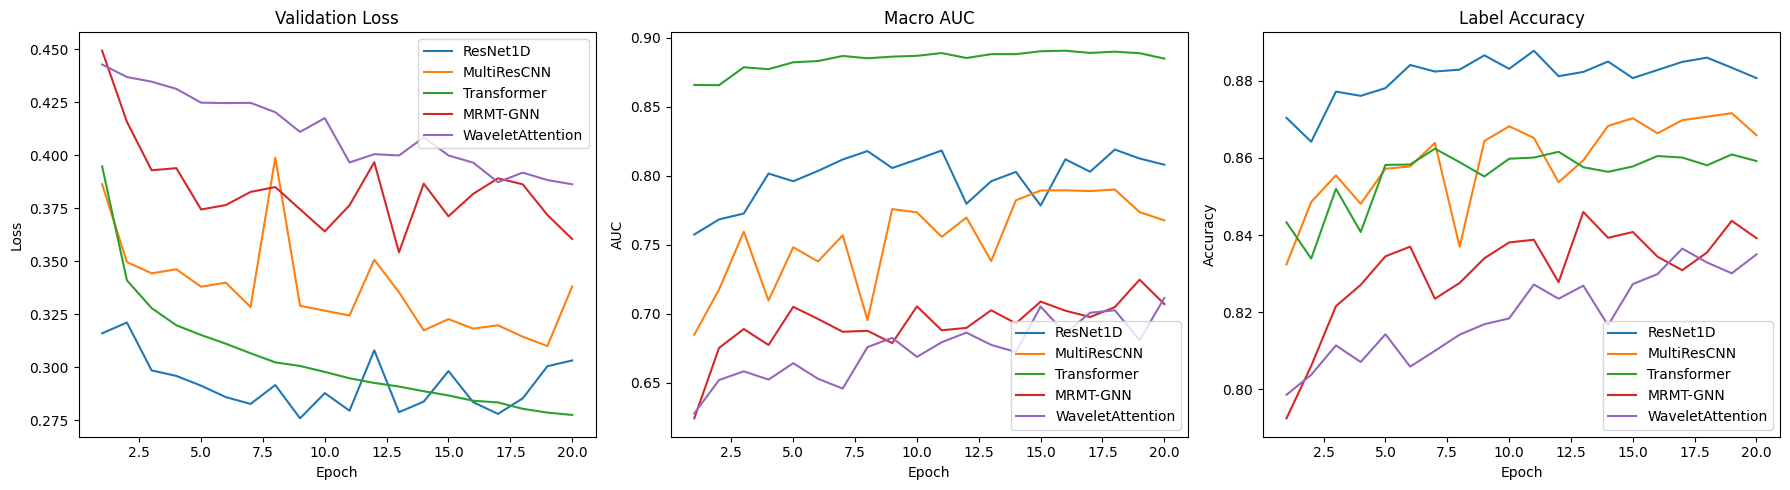

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, 21))

# ============================
# ResNet1D
# ============================
resnet_loss = [0.3159,0.3210,0.2984,0.2958,0.2912,0.2858,0.2826,0.2915,0.2758,0.2877,
               0.2794,0.3079,0.2787,0.2837,0.2981,0.2834,0.2779,0.2852,0.3004,0.3031]

resnet_auc = [0.7574,0.7683,0.7726,0.8016,0.7960,0.8035,0.8118,0.8179,0.8056,0.8118,
              0.8183,0.7797,0.7960,0.8028,0.7784,0.8119,0.8029,0.8190,0.8125,0.8080]

resnet_label = [0.8704,0.8642,0.8772,0.8761,0.8781,0.8841,0.8824,0.8829,0.8866,0.8831,
                 0.8878,0.8812,0.8823,0.8850,0.8807,0.8828,0.8849,0.8860,0.8834,0.8807]


# ============================
# MultiResCNN
# ============================
multires_loss = [0.3862,0.3495,0.3442,0.3461,0.3379,0.3398,0.3283,0.3988,0.3289,0.3266,
                 0.3243,0.3506,0.3353,0.3173,0.3226,0.3181,0.3197,0.3143,0.3099,0.3380]

multires_auc = [0.6847,0.7175,0.7594,0.7095,0.7481,0.7378,0.7568,0.6952,0.7758,0.7734,
                0.7557,0.7697,0.7381,0.7822,0.7893,0.7894,0.7889,0.7900,0.7736,0.7676]

multires_label = [0.8324,0.8486,0.8555,0.8481,0.8572,0.8578,0.8639,0.8370,0.8644,0.8682,
                  0.8652,0.8537,0.8594,0.8683,0.8703,0.8664,0.8698,0.8707,0.8716,0.8659]


# ============================
# MRMT-GNN
# ============================
mrmt_loss = [0.4492,0.4157,0.3928,0.3938,0.3743,0.3764,0.3826,0.3849,0.3744,0.3640,
             0.3763,0.3966,0.3541,0.3865,0.3711,0.3817,0.3890,0.3862,0.3717,0.3604]

mrmt_auc = [0.6240,0.6751,0.6888,0.6772,0.7049,0.6961,0.6868,0.6875,0.6786,0.7052,
            0.6879,0.6896,0.7024,0.6929,0.7087,0.7021,0.6975,0.7047,0.7246,0.7069]

mrmt_label = [0.7925,0.8061,0.8216,0.8271,0.8345,0.8370,0.8235,0.8276,0.8340,0.8381,
              0.8388,0.8278,0.8460,0.8393,0.8408,0.8344,0.8309,0.8355,0.8437,0.8392]


# ============================
# Transformer
# ============================
transformer_loss = [0.3946,0.3409,0.3278,0.3197,0.3151,0.3110,0.3065,0.3022,0.3005,0.2977,
                     0.2947,0.2925,0.2908,0.2886,0.2866,0.2841,0.2833,0.2803,0.2785,0.2774]

transformer_auc = [0.8659,0.8657,0.8787,0.8773,0.8823,0.8832,0.8869,0.8852,0.8864,0.8870,
                    0.8890,0.8854,0.8882,0.8882,0.8903,0.8907,0.8891,0.8900,0.8889,0.8850]

transformer_label = [0.8433,0.8339,0.8520,0.8408,0.8582,0.8583,0.8624,0.8589,0.8552,0.8598,
                      0.8601,0.8616,0.8576,0.8564,0.8578,0.8605,0.8601,0.8581,0.8609,0.8592]


# ============================
# WaveletAttention
# ============================
wavelet_loss = [0.4427,0.4368,0.4346,0.4312,0.4247,0.4245,0.4246,0.4202,0.4109,0.4174,
                0.3965,0.4004,0.3998,0.4083,0.3998,0.3964,0.3872,0.3917,0.3882,0.3862]

wavelet_auc = [0.6276,0.6518,0.6581,0.6521,0.6640,0.6527,0.6456,0.6757,0.6824,0.6686,
               0.6792,0.6862,0.6773,0.6721,0.7051,0.6856,0.7006,0.7024,0.6807,0.7113]

wavelet_label = [0.7986,0.8038,0.8114,0.8071,0.8143,0.8059,0.8100,0.8142,0.8169,0.8184,
                 0.8272,0.8235,0.8269,0.8166,0.8273,0.8299,0.8365,0.8329,0.8301,0.8350]


# ============================
# 3 Side-by-side Plots
# ============================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Loss ---
axes[0].plot(epochs, resnet_loss, label="ResNet1D")
axes[0].plot(epochs, multires_loss, label="MultiResCNN")
axes[0].plot(epochs, transformer_loss, label="Transformer")
axes[0].plot(epochs, mrmt_loss, label="MRMT-GNN")
axes[0].plot(epochs, wavelet_loss, label="WaveletAttention")
axes[0].set_title("Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# --- AUC ---
axes[1].plot(epochs, resnet_auc, label="ResNet1D")
axes[1].plot(epochs, multires_auc, label="MultiResCNN")
axes[1].plot(epochs, transformer_auc, label="Transformer")
axes[1].plot(epochs, mrmt_auc, label="MRMT-GNN")
axes[1].plot(epochs, wavelet_auc, label="WaveletAttention")
axes[1].set_title("Macro AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].legend()

# --- Label Accuracy ---
axes[2].plot(epochs, resnet_label, label="ResNet1D")
axes[2].plot(epochs, multires_label, label="MultiResCNN")
axes[2].plot(epochs, transformer_label, label="Transformer")
axes[2].plot(epochs, mrmt_label, label="MRMT-GNN")
axes[2].plot(epochs, wavelet_label, label="WaveletAttention")
axes[2].set_title("Label Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].legend()

plt.tight_layout()
plt.show()
